# Intelligent Financial Advisor using ML and Neural Networks

## Objective
Build an AI system that predicts financial risk level using income and expense data.

## Dataset
Financial dataset from Kaggle.

## Models Used
- Random Forest (Machine Learning)
- Neural Network (Deep Learning)

## Results
Random Forest Accuracy: 0.97
Neural Network Accuracy: 0.67

#IMPORT LIBRARIES

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

#EXPLORING DATASET

In [41]:
data =  pd.read_csv(r"C:\Users\shrej\Downloads\archive (1)\data.csv")



In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           20000 non-null  float64
 1   Age                              20000 non-null  int64  
 2   Dependents                       20000 non-null  int64  
 3   Occupation                       20000 non-null  object 
 4   City_Tier                        20000 non-null  object 
 5   Rent                             20000 non-null  float64
 6   Loan_Repayment                   20000 non-null  float64
 7   Insurance                        20000 non-null  float64
 8   Groceries                        20000 non-null  float64
 9   Transport                        20000 non-null  float64
 10  Eating_Out                       20000 non-null  float64
 11  Entertainment                    20000 non-null  float64
 12  Utilities         

In [43]:
print(data.columns)

Index(['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent',
       'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out',
       'Entertainment', 'Utilities', 'Healthcare', 'Education',
       'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings',
       'Disposable_Income', 'Potential_Savings_Groceries',
       'Potential_Savings_Transport', 'Potential_Savings_Eating_Out',
       'Potential_Savings_Entertainment', 'Potential_Savings_Utilities',
       'Potential_Savings_Healthcare', 'Potential_Savings_Education',
       'Potential_Savings_Miscellaneous'],
      dtype='object')


#CREATE RISK LEVEL

In [44]:
data["Savings_Ratio"] = data["Desired_Savings"] / data["Income"]

def risk_level(x):

    if x < 0.1:
        return "High"

    elif x < 0.25:
        return "Medium"

    else:
        return "Low"

data["Risk_Level"] = data["Savings_Ratio"].apply(risk_level)

data[["Income","Desired_Savings","Risk_Level"]].head()

,Income,Desired_Savings,Risk_Level
0,44637.249636,6200.537192,Medium
1,26858.596592,1923.176434,High
2,50367.605084,7050.360422,Medium
3,101455.600247,16694.965136,Medium
4,24875.283548,1874.099434,High


#FEATURE SELECTION

In [45]:
X = data[[
    "Age",
    "Income",
    "Rent",
    "Groceries",
    "Transport",
    "Eating_Out",
    "Entertainment",
    "Utilities"
]]

y = data["Risk_Level"]

In [46]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

#TRAIN TEST SPLIT

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#FEATURE SCALING

In [48]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#TRAIN ML MODEL

In [49]:
ml_model = RandomForestClassifier()

ml_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
ml_accuracy = ml_model.score(X_test, y_test)

print("Random Forest Accuracy:", ml_accuracy)

Random Forest Accuracy: 0.97525


#TRAIN NEURAL NETWORK

In [51]:
nn_model = Sequential()

nn_model.add(Dense(16, activation="relu", input_shape=(8,)))
nn_model.add(Dense(8, activation="relu"))
nn_model.add(Dense(3, activation="softmax"))

nn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

nn_model.fit(X_train, y_train, epochs=20)

Epoch 1/20


C:\Users\shrej\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6677 - loss: 11.2193
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8115 - loss: 0.5492
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8435 - loss: 0.4451
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8406 - loss: 0.4079
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8601 - loss: 0.3662
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8763 - loss: 0.3340
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8838 - loss: 0.3151
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.8904 - loss: 0.3053
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8939 - loss: 0.2904
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8991 - loss: 0.2840
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9026 - loss: 0.2811
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accur

#COMPARE ACCURACY

In [52]:
loss, nn_accuracy = nn_model.evaluate(X_test, y_test)

print("Neural Network Accuracy:", nn_accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8125 - loss: 0.3738
Neural Network Accuracy: 0.8125


In [53]:
#USER INPUT PREDICTION

In [54]:
age = int(input("Enter Age: "))
income = int(input("Enter Income: "))
rent = int(input("Enter Rent: "))
groceries = int(input("Enter Groceries Expense: "))
transport = int(input("Enter Transport Expense: "))
eating_out = int(input("Enter Eating Out Expense: "))
entertainment = int(input("Enter Entertainment Expense: "))
utilities = int(input("Enter Utilities Expense: "))

Enter Age:  40
Enter Income:  160000
Enter Rent:  15000
Enter Groceries Expense:  5000
Enter Transport Expense:  4000
Enter Eating Out Expense:  5000
Enter Entertainment Expense:  3500
Enter Utilities Expense:  8000


In [60]:
user_data = np.array([[
    age,
    income,
    rent,
    groceries,
    transport,
    eating_out,
    entertainment,
    utilities
]])

In [61]:
user_data_scaled = scaler.transform(user_data)

C:\Users\shrej\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [62]:
ml_prediction = ml_model.predict(user_data)

nn_prediction = nn_model.predict(user_data_scaled)

risk = nn_prediction.argmax()

print("ML Model Risk:", ml_prediction)
print("Neural Network Risk:", risk)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
ML Model Risk: [1]
Neural Network Risk: 0


C:\Users\shrej\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


#FINANCIAL ADVICE

In [63]:
if risk == 0:
    print("Low Risk Investor → Invest in Bonds / Fixed Deposits")

elif risk == 1:
    print("Medium Risk Investor → Balanced Portfolio (Mutual Funds + Stocks)")

else:
    print("High Risk Investor → Higher Stock / Equity Investment")

Low Risk Investor → Invest in Bonds / Fixed Deposits


#VIAUALIZATION

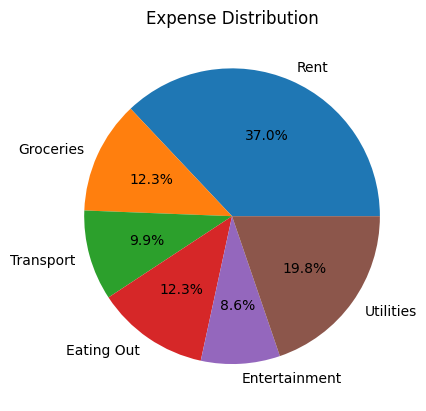

In [64]:
expenses = [rent, groceries, transport, eating_out, entertainment, utilities]

labels = [
    "Rent",
    "Groceries",
    "Transport",
    "Eating Out",
    "Entertainment",
    "Utilities"
]

plt.pie(expenses, labels=labels, autopct="%1.1f%%")

plt.title("Expense Distribution")

plt.show()